# Machine Learning Model Training

* ColumnTransformer 
* train different base models 
* tune hyper parameters using Bayesian Optimization
* Evaluate with cross-value and scoring
* Feature importances analysis

In [2]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import seaborn as sns

#from src.etl_turbine import *
#from train_predict import *
from src.config import *
from src.database import *
from src.feature_engineering import *
from modeling import *
from src.evaluation import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

In [22]:
# feature groups
numeric_features = (
    ["time_cycles", "setting1", "setting2", "setting3"]
    + [f"sensor{i}" for i in range(1, 22)]
)
categorical_features = ["condition", "fault_mode"]


In [23]:
df_train = load_complete_dataset("train")
df_test = load_complete_dataset("test")
df_train_test = pd.concat([df_train, df_test], ignore_index=True)
df_rul = load_rul_test()

create_database(DATABASE_URL, df_train_test, df_rul, DATASETS_META)


train data FD001: shape: (20631, 29)

train data FD002: shape: (74390, 29)

train data FD003: shape: (99110, 29)

train data FD004: shape: (160359, 29)

test data FD001: shape: (13096, 29)

test data FD002: shape: (47087, 29)

test data FD003: shape: (63683, 29)

test data FD004: shape: (104897, 29)

----------Database created successfully----------
Database saved: sqlite:///../db/turbofan_engine.db


## Load and prepare data

* Load data from database
* Prepare train, test, features and targets

In [3]:
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()
feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train, df_test, df_test_rul)


## Train base models

* LightGBM, XGBoost, RandomForest

In [4]:
# LightGBM model
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(random_state=42)
model_lgbm.fit(feature_train, target_train)
predictions = model_lgbm.predict(feature_test)  
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("LightGBM", eval_df["true_RUL"], eval_df["predicted_RUL"])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4099
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 25
[LightGBM] [Info] Start training from score 122.331338
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM              24.06      33.75     0.56


In [27]:
# XGBoost model
from xgboost import XGBRegressor
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(feature_train, target_train)
predictions = model_xgb.predict(feature_test)
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("XGBoost", eval_df["true_RUL"], eval_df["predicted_RUL"])

-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost               24.05      33.93     0.56


In [28]:
# random forest model
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)
model_rf.fit(feature_train, target_train)
predictions = model_rf.predict(feature_test)
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("Random Forest", eval_df["true_RUL"], eval_df["predicted_RUL"])

-------------------- scoring --------------------
model                  MAE       RMSE       R²
Random Forest         24.12      34.50     0.54


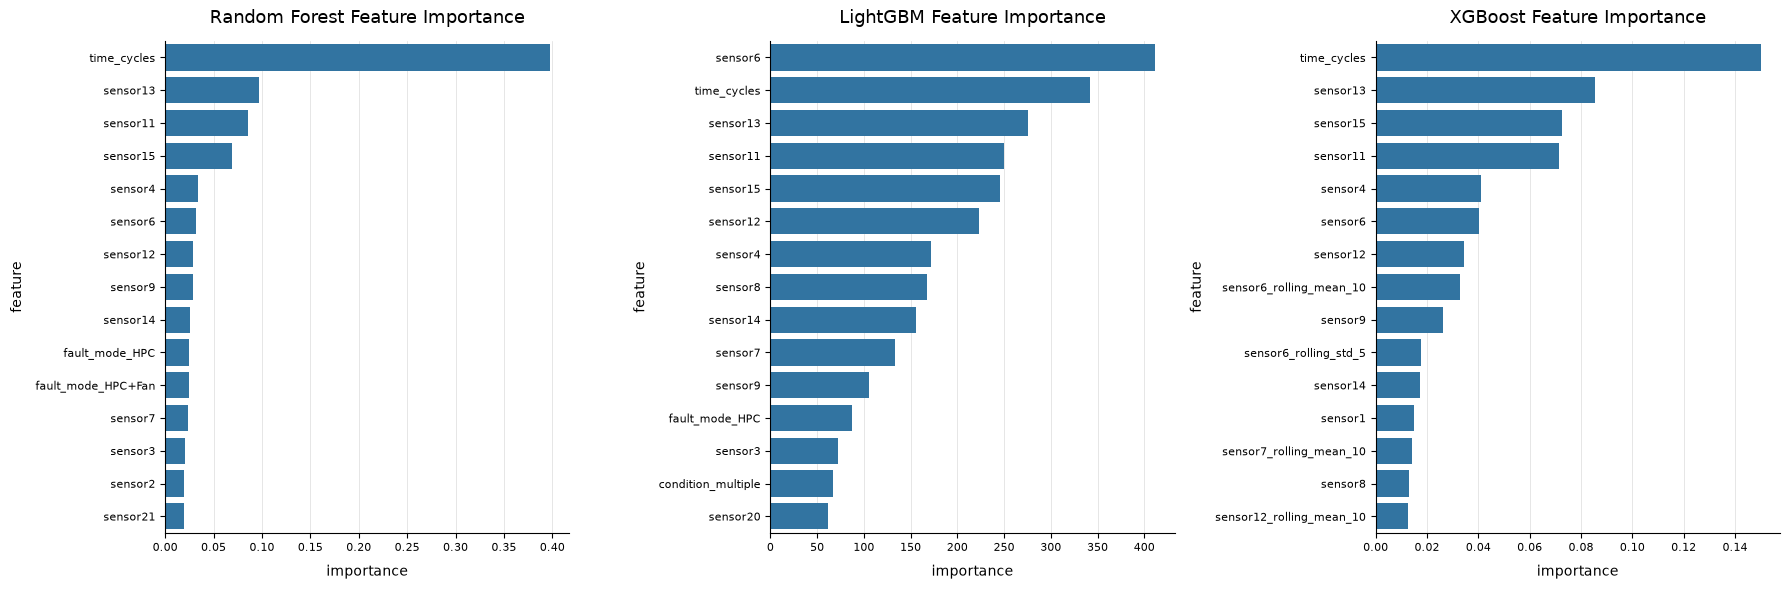

In [65]:
# plot feature importance of top 15 features for 3 models
importances_rf = sorted(model_rf.feature_importances_.tolist(), reverse=True)
importances_lgbm = sorted(model_lgbm.feature_importances_.tolist(), reverse=True)
importances_xgb = sorted(model_xgb.feature_importances_.tolist(), reverse=True)

df_feature_importance_rf = pd.DataFrame({
    "feature": feature_train.columns,   
    "importance": model_rf.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)
df_feature_importance_lgbm = pd.DataFrame({
    "feature": feature_train.columns,   
    "importance": model_lgbm.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)
df_feature_importance_xgb = pd.DataFrame({
    "feature": model_xgb.get_booster().feature_names,   
    "importance": model_xgb.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)

#feature_names = feature_train.columns
xgb_features = model_xgb.get_booster().feature_names

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.barplot(x=df_feature_importance_rf["importance"], y=df_feature_importance_rf["feature"], ax=axes[0])
axes[0].set_title("Random Forest Feature Importance")
sns.barplot(x=df_feature_importance_lgbm["importance"], y=df_feature_importance_lgbm["feature"], ax=axes[1])
axes[1].set_title("LightGBM Feature Importance")
sns.barplot(x=df_feature_importance_xgb["importance"], y=df_feature_importance_xgb["feature"], ax=axes[2])
axes[2].set_title("XGBoost Feature Importance") 
plt.tight_layout()
plt.show()

# Feature selection and engineering

* tried rolling features with windows 5 an 10. 
    - No improvement -> discard
* select most import sensors according to feature importance analysis
* feature engineering 
    - clip RUL: dfferent max_rul -> different scoring R²  
    - build delta 1 and 5 on important sensors 

In [ ]:
#important_sensors_in_top_15 = [13,11,15,4,6,12,9,14,7,3,2,1,21, 8, 14, 20, 10, 5]
important_sensors_sorted = [4, 5, 6, 7, 9, 11, 12, 13, 14, 14, 15]
print("Most important sensors across models:", important_sensors_sorted)
print(len(important_sensors_sorted))

Most important sensors across models: [4, 5, 6, 7, 9, 11, 12, 13, 14, 14, 15]
11


In [21]:
# complete data pipeline to engineer new features based on the most important sensors and evaluate model performance again
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()

# engineer new features based on the most important sensors and evaluate model performance again
df_train_engineered = create_sensor_delta(df_train, important_sensors_sorted)
df_train_engineered = clip_rul(df_train_engineered, max_rul=150)
df_test_engineered = create_sensor_delta(df_test, important_sensors_sorted)

feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train_engineered, df_test_engineered, df_test_rul)


In [22]:
# LightGBM model
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(random_state=42)
model_lgbm.fit(feature_train, target_train)
predictions = model_lgbm.predict(feature_test)  
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("LightGBM", eval_df["true_RUL"], eval_df["predicted_RUL"])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 45
[LightGBM] [Info] Start training from score 99.942978
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM              18.41      24.79     0.76


In [23]:
# XGBoost model
from xgboost import XGBRegressor
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(feature_train, target_train)
predictions = model_xgb.predict(feature_test)
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("XGBoost", eval_df["true_RUL"], eval_df["predicted_RUL"])

-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost               18.30      24.64     0.77


In [27]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Investigate different RUL caps to see how it affects model performance, especially for the critical end-of-cycle predictions
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()

# engineer new features based on the most important sensors and evaluate model performance again
df_train_engineered = create_sensor_delta(df_train, important_sensors_sorted)
df_test_engineered = create_sensor_delta(df_test, important_sensors_sorted)

caps = [75, 100, 125, 150, 175, 200, 250, None]
for cap in caps:
     df_train_tmp = df_train_engineered.copy()
     df_train_tmp = clip_rul(df_train_tmp, max_rul=cap)
     feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train_tmp, df_test_engineered, df_test_rul)
     
     model_lgbm = LGBMRegressor(random_state=42)
     model_lgbm.fit(feature_train, target_train)
     predictions = model_lgbm.predict(feature_test)  
     eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
     print_scores(f"LightGBM max_rul: {cap}", eval_df["true_RUL"], eval_df["predicted_RUL"])

     model_xgb = XGBRegressor(random_state=42)
     model_xgb.fit(feature_train, target_train)
     predictions = model_xgb.predict(feature_test)
     eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
     print_scores(f"XGBoost max_rul: {cap}", eval_df["true_RUL"], eval_df["predicted_RUL"])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 45
[LightGBM] [Info] Start training from score 62.399211
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM max_rul: 75      30.41      42.83     0.30
-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost max_rul: 75      30.24      42.73     0.30
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 45
[LightGBM] [Info] Start training from score 77.672285
---------------

## Tune models 

* Selected models: LightGBM and XGBoost
* With re-engineered features
* Use Bayesian Optimization

In [9]:
# complete data pipeline to engineer new features based on the most important sensors and evaluate model performance again
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()

important_sensors_sorted = [4, 5, 6, 7, 9, 11, 12, 13, 14, 14, 15]
# engineer new features based on the most important sensors and evaluate model performance again
df_train_engineered = create_sensor_delta(df_train, important_sensors_sorted)
df_train_engineered = clip_rul(df_train_engineered, max_rul=150)
df_test_engineered = create_sensor_delta(df_test, important_sensors_sorted)

feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train_engineered, df_test_engineered, df_test_rul)

In [ ]:
# LightGBM model
from datetime import datetime

from lightgbm import LGBMRegressor

lgbm_paramters = {
    "learning_rate": (0.01, 0.2),
    "num_leaves": (16, 128),
    "max_depth": (3, 12),
    "min_child_samples": (5, 100),
    "feature_fraction": (0.6, 1.0),
    "bagging_fraction": (0.6, 1.0),
}
start_time = datetime.now()
model_lgbm = LGBMRegressor(random_state=42)
best_lgbm, best_params_lgbm = tune_model_bayesian(model_lgbm, lgbm_paramters, feature_train, target_train)
    
best_lgbm.fit(feature_train, target_train)
predictions_lgbm = best_lgbm.predict(feature_test)  
save_model_to_pickle(best_lgbm, "../models/best_lgbm_model.pkl")
eval_df_lgbm = create_eval_dataframe_from_predictions(predictions_lgbm, df_test, df_test_rul)

end_time = datetime.now()
print(f"LightGBM train time: {(end_time - start_time).total_seconds()/60:.0f}'{(end_time - start_time).total_seconds()%60:.0f}''")

print("Best LightGBM Parameters:", best_params_lgbm)
print_scores("Tuned LightGBM", eval_df_lgbm["true_RUL"], eval_df_lgbm["predicted_RUL"]) 


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 45
[LightGBM] [Info] Start training from score 99.942978
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [14]:
# tune XGBoost
from datetime import datetime
from xgboost import XGBRegressor

xgb_parameters = {
    "learning_rate": (0.01, 0.2),
    "max_depth": (3, 10),
    "min_child_weight": (1, 20),
    "subsample": (0.6, 1.0),
    "colsample_bytree": (0.6, 1.0),
}

start_time = datetime.now()
model_xgb = XGBRegressor(random_state=42)
best_xgb, best_params_xgb = tune_model_bayesian(model_xgb, xgb_parameters, feature_train, target_train)

best_xgb.fit(feature_train, target_train)
predictions_xgb = best_xgb.predict(feature_test)  
eval_df_xgb = create_eval_dataframe_from_predictions(predictions_xgb, df_test, df_test_rul)
save_model_to_pickle(best_xgb, "../models/best_xgb_model.pkl")

end_time = datetime.now()
print(f"XGBoost train time: {(end_time - start_time).total_seconds()/60:.0f}'{(end_time - start_time).total_seconds()%60:.0f}''")

print("Best XGBoost Parameters:", best_params_xgb)
print_scores("Tuned XGBoost", eval_df_xgb["true_RUL"], eval_df_xgb["predicted_RUL"])

XGBoost train time: 9'54''
Best XGBoost Parameters: OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.07965498761802602, 'max_depth': 10, 'min_child_weight': 20, 'subsample': 1.0})
-------------------- scoring --------------------
model                  MAE       RMSE       R²
Tuned XGBoost         17.82      24.33     0.77


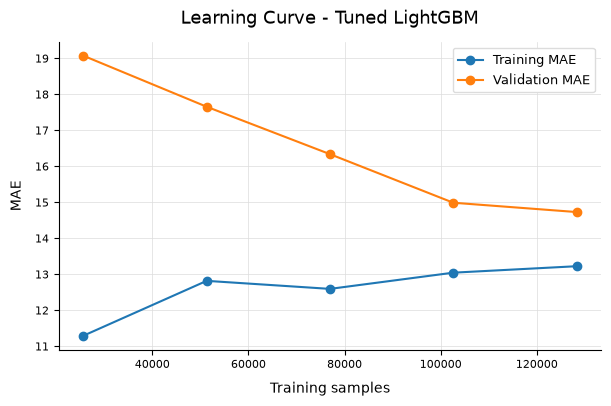

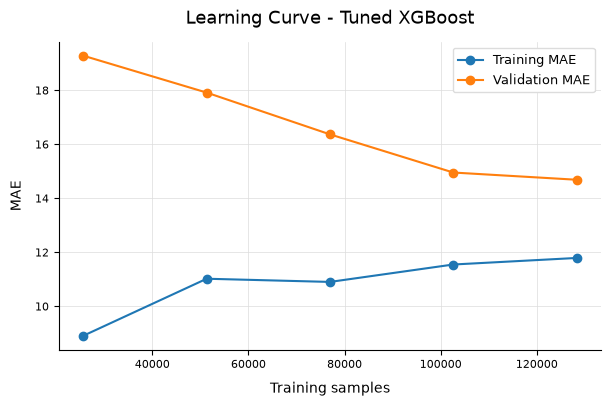

In [36]:
# Learning curve of both models
plot_learning_curve_grouped(best_lgbm, "Tuned LightGBM", feature_train, target_train, df_train_engineered)
plot_learning_curve_grouped(best_xgb, "Tuned XGBoost", feature_train, target_train, df_train_engineered)


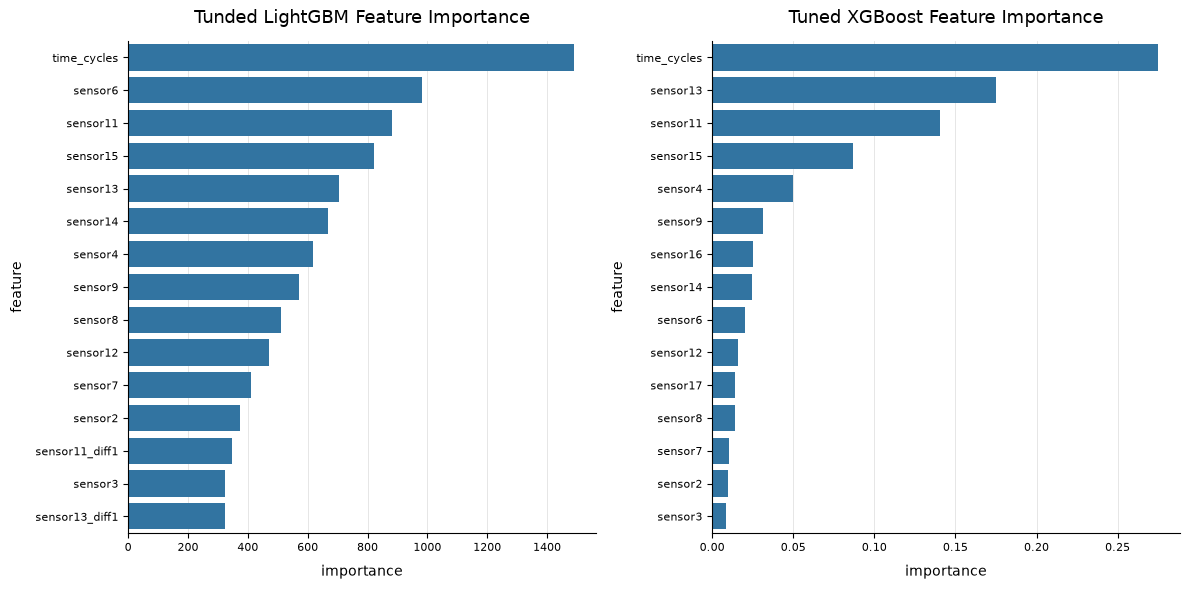

In [10]:
best_lgbm = load_model_from_pickle("../models/best_lgbm_model.pkl")
best_xgb = load_model_from_pickle("../models/best_xgb_model.pkl")

# plot feature importance of top 15 features for 2 tuned models
importances_lgbm = sorted(best_lgbm.feature_importances_.tolist(), reverse=True)
importances_xgb = sorted(best_xgb.feature_importances_.tolist(), reverse=True)

df_feature_importance_lgbm = pd.DataFrame({
    "feature": feature_train.columns,   
    "importance": best_lgbm.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)
df_feature_importance_xgb = pd.DataFrame({
    "feature": best_xgb.get_booster().feature_names,   
    "importance": best_xgb.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)

#feature_names = feature_train.columns
xgb_features = best_xgb.get_booster().feature_names

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(x=df_feature_importance_lgbm["importance"], y=df_feature_importance_lgbm["feature"], ax=axes[0])
axes[0].set_title("Tunded LightGBM Feature Importance")
sns.barplot(x=df_feature_importance_xgb["importance"], y=df_feature_importance_xgb["feature"], ax=axes[1])
axes[1].set_title("Tuned XGBoost Feature Importance") 
plt.tight_layout()
plt.show()

In [11]:
# save feature importance dataframes to csv for later use in dashboard
df_feature_importance_lgbm.to_csv("../models/feature_importance_lgbm.csv", index=False)
df_feature_importance_xgb.to_csv("../models/feature_importance_xgb.csv", index=False)

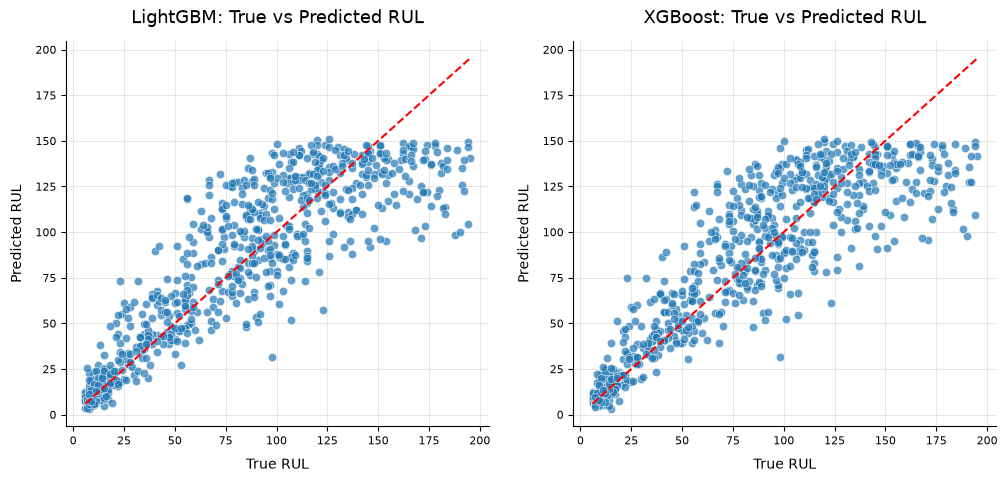

In [30]:
# plot true vs predicted RUL for LightGBM and XGBoost
fig, axes = plt.subplots(1,2, figsize=(12, 5))
sns.scatterplot(x=eval_df_lgbm["true_RUL"], y=eval_df_lgbm["predicted_RUL"], alpha=0.7, ax=axes[0])
axes[0].plot([eval_df_lgbm["true_RUL"].min(), eval_df_lgbm["true_RUL"].max()], [eval_df_lgbm["true_RUL"].min(), eval_df_lgbm["true_RUL"].max()], 'r--')
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("LightGBM: True vs Predicted RUL")

sns.scatterplot(x=eval_df_xgb["true_RUL"], y=eval_df_xgb["predicted_RUL"], alpha=0.7, ax=axes[1])
axes[1].plot([eval_df_xgb["true_RUL"].min(), eval_df_xgb["true_RUL"].max()], [eval_df_xgb["true_RUL"].min(), eval_df_xgb["true_RUL"].max()], 'r--')
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel("Predicted RUL")
axes[1].set_title("XGBoost: True vs Predicted RUL")
plt.show()

# Evaluate prediction on four datasets separately

* prepare test dataframes for different datasets
* use best models to predict on test dataframes
* compare results 

In [ ]:
# prepare test data for different datasets
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()

#important_sensors_sorted = [4, 5, 6, 7, 9, 11, 12, 13, 14, 14, 15]
df_train_engineered = create_sensor_delta(df_train, important_sensors_sorted)
df_train_engineered = clip_rul(df_train_engineered, max_rul=150)
df_test_engineered = create_sensor_delta(df_test, important_sensors_sorted)
df_test_engineered = create_sensor_delta(df_test, important_sensors_sorted)

In [ ]:
for dataset_id in df_test_engineered["dataset_id"].unique():
    df_test_engineered_subset = df_test_engineered.loc[df_test_engineered["dataset_id"] == dataset_id]
    df_test_rul.loc[df_test_rul["dataset_id"] == dataset_id, "true_RUL"] = df_test_rul.loc[df_test_rul["dataset_id"] == dataset_id, "true_RUL"]

    feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train_engineered, df_test_engineered, df_test_rul)

    predictions_lgbm = best_lgbm.predict(feature_test)  
    eval_df_lgbm = create_eval_dataframe_from_predictions(predictions_lgbm, df_test, df_test_rul)
    print_scores(f"LightGBM on {dataset_id}", eval_df_lgbm["true_RUL"], eval_df_lgbm["predicted_RUL"])

    predictions_xgb = best_xgb.predict(feature_test)  
    eval_df_xgb = create_eval_dataframe_from_predictions(predictions_xgb, df_test, df_test_rul)
    print_scores(f"XGBoost on {dataset_id}", eval_df_xgb["true_RUL"], eval_df_xgb["predicted_RUL"])
    

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM on FD001      17.98      24.40     0.77
-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost on FD001      17.82      24.33     0.77
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM on FD002      17.98      24.40     0.77
-------------------- scoring --------------------
model                  MAE     

## Findings

* Both models work stably on four test data sets separately

| Model     | Dataset | MAE      | RMSE    | R²    |
| --- | --- | --- | --- | --- |
| LightGBM  | FD001   | 17.98    | 24.40   | 0.77  |
| XGBoost   | FD001   | 17.82    | 24.33   | 0.77  |
| LightGBM  | FD002   | 17.98    | 24.40   | 0.77  |
| XGBoost   | FD002   | 17.82    | 24.33   | 0.77  |
| LightGBM  | FD003   | 17.98    | 24.40   | 0.77  |
| XGBoost   | FD003   | 17.82    | 24.33   | 0.77  |
| LightGBM  | FD004   | 17.98    | 24.40   | 0.77  |
| XGBoost   | FD004   | 17.82    | 24.33   | 0.77  |

## Conclusion:

* Both LightGBM and XGBoost show improved performance after tuning hyperparameters and engineering features based on the most important sensors.
* The feature importance analysis revealed that certain sensors (e.g., sensor13, sensor11, sensor15) consistently ranked as the most important across models, guiding the feature engineering process.
* Clipping max RUL leads to further improvement. RUL towards the end of the cycle is critical for maintenance decisions, while predictions for early cycles are more dispersed.    

Improvement Table:
| Steps                       | XGBoost MAE |       R² |
| ----------------------------- | ----------: | -------: |
| Baseline Model        |      ~24.15 |     0.55 |
| + Feature Engineering         |      ~18.69 |     0.74 |
| + Optimales RUL-Capping (150) |   **18.30** | **0.77** |

